<a href="https://colab.research.google.com/github/ZhannaPavlova/colab/blob/main/pharma_funnel_visible_source_png.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

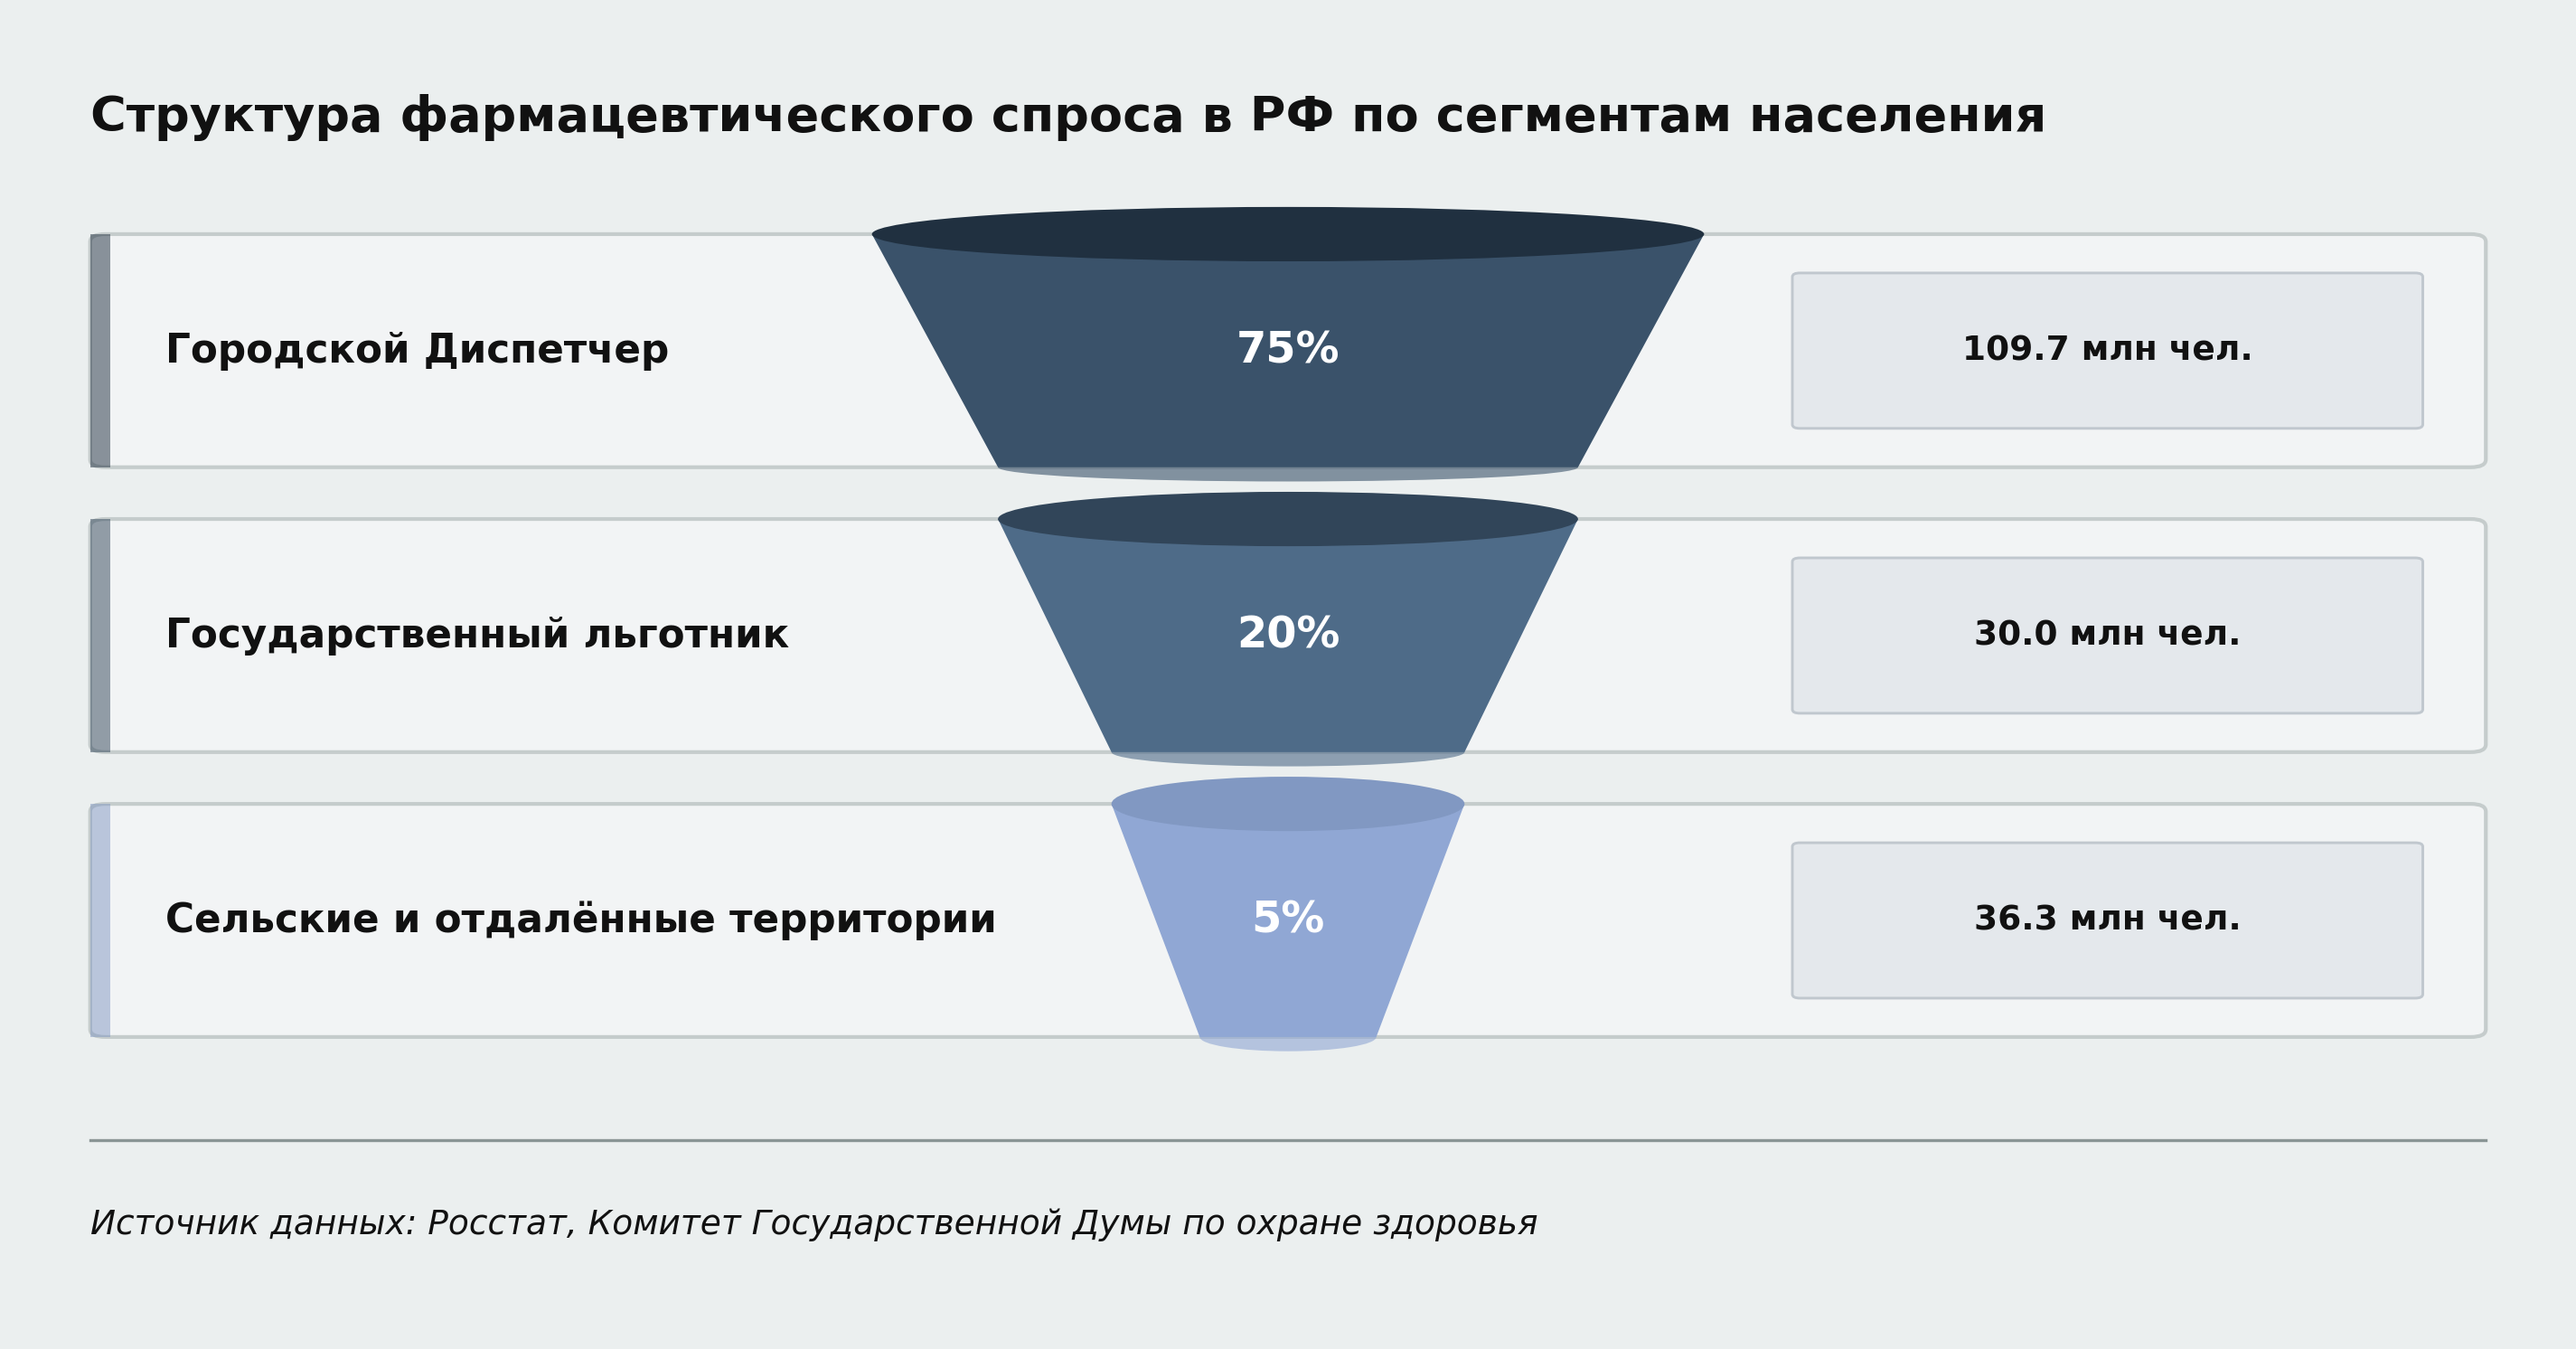

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Настройка холста
fig, ax = plt.subplots(figsize=(12, 6.2), dpi=300)
fig.patch.set_facecolor('#EBEFEF')
ax.set_facecolor('#EBEFEF')
ax.axis('off')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

# Цветовая палитра
GRAY_TEXT = '#111111'
GRAY_SUB = '#555555'
GRAY_CARD_BG = '#F2F4F5'
GRAY_BORDER = '#C5CCCC'
GRAY_LINE = '#8A9595'  # Сделали линию чуть более контрастной

# --- ОСНОВНОЙ ЗАГОЛОВОК ---
ax.text(2.5, 92.0, "Структура фармацевтического спроса в РФ по сегментам населения",
        fontsize=13, fontweight='bold', color=GRAY_TEXT, family='sans-serif')

# --- ДАННЫЕ ---
data = [
    {
        "title": "Городской Диспетчер",
        "percent": "75%",
        "abs_val": "109.7 млн чел.",
        "color_top": "#203040",
        "color_body": "#3A526A"
    },
    {
        "title": "Государственный льготник",
        "percent": "20%",
        "abs_val": "30.0 млн чел.",
        "color_top": "#314559",
        "color_body": "#4E6B88"
    },
    {
        "title": "Сельские и отдалённые территории",
        "percent": "5%",
        "abs_val": "36.3 млн чел.",
        "color_top": "#8198C2",
        "color_body": "#90A7D4"
    }
]

y_positions = [66, 44, 22]
row_height = 18.0
X_CENTER = 50.0

# Геометрия 3D-воронки
funnel_widths = [
    {"top": 33.0, "bottom": 23.0},
    {"top": 23.0, "bottom": 14.0},
    {"top": 14.0, "bottom": 7.0}
]

for i, d in enumerate(data):
    y = y_positions[i]
    y_center = y + row_height / 2.0
    fw = funnel_widths[i]

    # 1. Фоновая карточка
    card = patches.FancyBboxPatch(
        (2.5, y), 95.0, row_height,
        boxstyle="round,pad=0.0,rounding_size=0.6",
        facecolor=GRAY_CARD_BG, edgecolor=GRAY_BORDER, linewidth=1.0
    )
    ax.add_patch(card)

    # Левая полоса-акцент
    edge_strip = patches.Rectangle((2.5, y), 0.8, row_height, facecolor=d["color_top"], alpha=0.5)
    ax.add_patch(edge_strip)

    # 2. Название категории (по левому краю)
    ax.text(5.5, y_center, d["title"],
            fontsize=10.5, fontweight='bold', color=GRAY_TEXT, va='center', ha='left', family='sans-serif')

    # 3. 3D-ВОРОНКА
    trap = patches.Polygon([
        [X_CENTER - fw["top"]/2.0, y + row_height],
        [X_CENTER + fw["top"]/2.0, y + row_height],
        [X_CENTER + fw["bottom"]/2.0, y],
        [X_CENTER - fw["bottom"]/2.0, y]
    ], facecolor=d["color_body"], edgecolor='none')
    ax.add_patch(trap)

    ellipse_top = patches.Ellipse(
        (X_CENTER, y + row_height), fw["top"], 4.2,
        facecolor=d["color_top"], edgecolor='none'
    )
    ax.add_patch(ellipse_top)

    ellipse_bottom = patches.Ellipse(
        (X_CENTER, y), fw["bottom"], 2.2,
        facecolor=d["color_body"], edgecolor='none', alpha=0.6
    )
    ax.add_patch(ellipse_bottom)

    # Процент внутри воронки
    ax.text(X_CENTER, y_center, d["percent"],
            fontsize=11.5, fontweight='bold', color='#FFFFFF', ha='center', va='center')

    # 4. ПРАВАЯ ИНФОРМАЦИОННАЯ КАРТОЧКА
    info_box_w = 25.0
    info_box_h = row_height - 6.0
    info_x = 70.0
    info_y = y + 3.0

    info_bg = patches.FancyBboxPatch(
        (info_x, info_y), info_box_w, info_box_h,
        boxstyle="round,pad=0.0,rounding_size=0.3",
        facecolor='#E4E8EC', edgecolor='#C0C7CE', linewidth=0.7
    )
    ax.add_patch(info_bg)

    ax.text(info_x + info_box_w / 2.0, info_y + info_box_h / 2.0, d["abs_val"],
            fontsize=9.0, fontweight='bold', color=GRAY_TEXT, va='center', ha='center', family='sans-serif')

# ==========================================
# ПОДВАЛ С ВЫСОКИМ КОНТРАСТОМ И ЧЕТКИМ ТЕКСТОМ
# ==========================================

# 1. Разделительная линия над подвалом
ax.plot([2.5, 97.5], [14.0, 14.0], color=GRAY_LINE, linewidth=0.8)

# 2. Текст источника данных (цвет #111111 — темный/четкий, размер 9)
ax.text(2.5, 7.5, "Источник данных: Росстат, Комитет Государственной Думы по охране здоровья",
        fontsize=9, color='#111111', fontweight='normal', style='italic', va='center', family='sans-serif')

# 3. Фиксация нижней границы холста, чтобы обрезка не задевала текст
ax.plot([0, 100], [0, 0], alpha=0)

# Сохранение файла
plt.savefig('pharma_funnel_visible_source.png', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()